# Hardware AES Power Trace Acquisition for TVLA

This notebook performs the **online phase** of the side-channel workflow targeting a hardware implementation of AES on the CW305 FPGA board. 

Specifically, this notebook is configured for **Test Vector Leakage Assessment (TVLA)**. It acquires power traces while feeding the hardware either a **fixed** plaintext or a **random** plaintext. The choice between fixed and random is non-deterministic (randomly interleaved) to ensure the internal state of the device is randomized prior to each encryption.

Traces, plaintexts, ciphertexts, and the corresponding TVLA labels (`0` for fixed, `1` for random) are saved directly into an **HDF5 (`.h5`) format** for optimized reading in the offline analysis notebooks.

In [ ]:
import os
import sys
import time
from tqdm import tqdm
import h5py
from pathlib import Path
import numpy as np
from tqdm.notebook import tnrange

## Project paths
This block robustly detects the project root (`DOJO_ROOT`) starting from either the script location (`__file__`) or the current working directory (for notebooks). From there it defines all relevant subdirectories ( sources, SCA scripts, X-HEEP, traces, plots, cache), ensures output folders exist, and adds the local source paths to `sys.path` .

In [2]:
def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )


# In a script, __file__ exists; in a notebook, it does not.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: use the current working directory instead
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
AES_PY_DIR  = DOJO_ROOT / "sw" / "ciphers" / "AES_python"
SCA_DIR     = DOJO_ROOT / "sw" / "sca_scripts"
HW_DIR      = DOJO_ROOT / "hw"

# Traces and plots PATH for  SW
TRACESET_DIR = DOJO_ROOT / "sw" / "traceset" / "AES" / "hw"
BASE_PLOT_DIR = DOJO_ROOT / "sw" / "sca_scripts" / "AES" / "hw" / "plot"

TRACESET_DIR.mkdir(parents=True, exist_ok=True)
BASE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Make local modules importable 
sys.path.insert(0, str(AES_PY_DIR))
sys.path.insert(0, str(SCA_DIR))

In [3]:
from pico_api import PS5000aWrapper
from CW305_api import CW305Wrapper
from AES_golden import AES_golden_model
from analyzer.utils.sca_plots import sca_plot

# Configuration

In [4]:
capture = True
save_dataset = True

# ---------------------------------------------------------------------------
# TVLA Configuration
# ---------------------------------------------------------------------------
n_fixed = 10000
n_random = 10000
n_trc = n_fixed + n_random

# Enforce standard AES S-Box
sbox_id = "rijandael" 

traces_overlapped_plot = True   # Plot overlapped power traces
save_plot              = True   # Save overlapped plot to disk

# Fixed path definition using pathlib logic
bitstream_path = (
    HW_DIR
    / "fpga"
    / "bitstream"
    / "aes"
    / "aes_single_round"
    / f"cw305_top_{sbox_id}_lut.bit"
)

bitstream = str(bitstream_path)

# Traces file path (board-captured traces)
TRACESET_FILE = TRACESET_DIR / f"aes_{sbox_id}_{n_trc // 1000}k_tvla.h5"

# Directory for plots for this sub-layer
PLOT_DIR = BASE_PLOT_DIR / f"{sbox_id}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Helper for pretty yes/no printing
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    return "yes" if flag else "no"

# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------
print("\n================= AES HW TVLA CAPTURE CONFIGURATION =================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  S-box type        : {sbox_id}")
print()
print("Paths")
print(f"  Bitstream         : {bitstream_path}")
print(f"  HW traces file    : {TRACESET_FILE}")
print(f"  SCA traces dir    : {TRACESET_DIR}")
print(f"  Plot dir          : {PLOT_DIR}")
print("Online phase")
print(f"  Number of traces  : {n_trc} ({n_fixed} fixed, {n_random} random)")
print(f"  Save dataset      : {_yn(save_dataset)}")
print(f"  Overlapped plot   : {_yn(traces_overlapped_plot)}")
print(f"  Save plot         : {_yn(save_plot)}")
print("=====================================================================\n")


================= AES HW TVLA CAPTURE CONFIGURATION =================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  S-box type        : rijandael

Paths
  Bitstream         : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/hw/fpga/bitstream/aes/aes_single_round/cw305_top_rijandael_lut.bit
  HW traces file    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/hw/aes_rijandael_20k_tvla.h5
  SCA traces dir    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/hw
  Plot dir          : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/hw/plot/rijandael
Online phase
  Number of traces  : 20000 (10000 fixed, 10000 random)
  Save dataset      : yes
  Overlapped plot   : yes
  Save plot         : yes



# Board preparation

In [5]:
def prepare_board(bitstream):
    """
    Prepare the CW305 board for the attack:
      1. Initialize the PicoScope.
      2. Initialize CW305 with the given bitstream.

    Returns:
        (ps, cw305) handles for scope and board.
    """
    try:
        # 1) Initialize PicoScope
        ps = PS5000aWrapper()
        ps.get_unitInfo()
        
        # The scope is triggered before the registers update, and it is set for only 34 clock cycles.
        ps.scope_setup(obs_time=3.5E-6, nSamples=350) # ~3.5 us, 350 samples
        
        # Safely get the number of samples (handles different versions of the wrapper)
        num_samples = getattr(ps, 'nSamples', None) or ps.get_nSamples()
        
        # 2) Initialize CW305
        cw305 = CW305Wrapper(ps, bitstream)
        
        return ps, cw305
        
    except Exception as e:
        # Catching Exception is safer than just ModuleNotFoundError, 
        # as it will also catch USB disconnection or missing bitstream errors.
        print(f"Error during board preparation: {e}")
        raise

## Online phase : AES HW power traces capture

The parameters below dictate the TVLA capture set. We enforce the use of the standard `rijandael` S-Box and aim to collect 10,000 fixed traces and 10,000 random traces (20,000 total).

In [6]:
# TVLA Random Interleaving: 0 for fixed, 1 for random
labels = np.array([0] * n_fixed + [1] * n_random, dtype=np.uint8)
np.random.shuffle(labels)

# Fixed key and fixed plaintext for TVLA
key = [0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6,
       0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C]
fixed_text = [0x6B, 0xC1, 0xBE, 0xE2, 0x2E, 0x40, 0x9F, 0x96,
              0xE9, 0x3D, 0x7E, 0x11, 0x73, 0x93, 0x17, 0x2A]

# Initialize the AES software emulated cipher for sanity checking
cipher = AES_golden_model()

# Each element of the key is converted to a 2-digit hex string 
formatted_key = ''.join(format(el, '02x') for el in key)
print(f"[ONLINE] Fixed key used for acquisition (hex): {formatted_key}")

print(f"[ONLINE] Trace acquisition enabled. Target traces: {n_trc} ({n_fixed} fixed, {n_random} random)")
print(f"[ONLINE] Using bitstream      : {bitstream}")
print(f"[ONLINE] HDF5 traceset target : {TRACESET_FILE}")

# -----------------------------------------------------------------------
# Prepare board (PicoScope + CW305)
# -----------------------------------------------------------------------
try:
    # Pass the bitstream argument to the prepare function
    ps, cw305 = prepare_board(bitstream)
    print("\n[ONLINE] Board initialized successfully.")
    
    try:
        print("[ONLINE] Picoscope settings:")
        print(ps.get_scopeSettings())
    except AttributeError:
        pass # Method might not exist in HW wrapper

    # Extract required scope properties for array allocation and metadata
    n_samples = getattr(ps, 'nSamples', None) or ps.get_nSamples()
    
    try:
        sampling_interval = ps.get_samplingInterval()
    except AttributeError:
        sampling_interval = 8e-9 # Fallback if method doesn't exist
        
    print(f"[ONLINE] Sampling Interval   : {sampling_interval} s\n")

except Exception as e:
    print(f"[ERROR] Failed to prepare board (PicoScope + CW305): {e}")
    raise

# -----------------------------------------------------------------------
# Trace acquisition 
# -----------------------------------------------------------------------
traces = None
plaintexts = None
ciphertexts = None

try:
    # Write the key to the CW305
    cw305.set_key(key)

    # Dummy capture call due to bug of using AC coupling
    cw305.capture_trace(fixed_text)

    # Initialize storage arrays (now n_samples is properly defined)
    traces = np.empty((n_trc, n_samples), dtype=float)
    plaintexts = np.empty((n_trc, 16), dtype=np.uint8)
    ciphertexts = np.empty((n_trc, 16), dtype=np.uint8)

    print("[ONLINE] Starting TVLA trace capture...")
    for i in tqdm(range(n_trc), desc="Capturing traces"):
        
        # TVLA Random Selection
        if labels[i] == 0:
            current_text = fixed_text
        else:
            # Generate a random 16-byte plaintext
            current_text = list(np.random.randint(0, 256, 16, dtype=np.uint8))

        # Hardware capture
        captured_ct, captured_trace = cw305.capture_trace(current_text)
        
        # Store in arrays
        traces[i] = captured_trace
        plaintexts[i] = current_text
        ciphertexts[i] = captured_ct

        # Sanity check with expected ciphertext
        expected_ct = cipher.encrypt(formatted_key, current_text, "sbox_" + sbox_id)
        assert (list(captured_ct) == list(expected_ct)), \
            f"Incorrect encryption result!\nGot {list(captured_ct)}\nExp {list(expected_ct)}\n"

    # -------------------------------------------------------------------
    # Save traces to HDF5
    # -------------------------------------------------------------------
    if save_dataset:
        print("[ONLINE] Saving traces to HDF5...")
        with h5py.File(TRACESET_FILE, "w") as f_write_traces:
            f_write_traces.create_dataset("traces", data=traces)
            f_write_traces.create_dataset("labels", data=labels)
            f_write_traces.create_dataset("plaintexts", data=plaintexts)
            f_write_traces.create_dataset("ciphertexts", data=ciphertexts)
            
            # Store metadata as attributes
            f_write_traces.attrs["sampling_interval"] = sampling_interval
            f_write_traces.attrs["n_traces"] = n_trc
            f_write_traces.attrs["n_samples"] = n_samples
            f_write_traces.attrs["key_hex"] = formatted_key
            f_write_traces.attrs["sbox"] = sbox_id

        print(f"[ONLINE] Capture completed. Traces saved to: {TRACESET_FILE}")
    else:
        print("[ONLINE] Capture completed. Traces were not saved (save_dataset = False).")

except Exception as e:
    print(f"[ERROR] Capture aborted due to error: {e}")
    raise
finally:
    # Disconnect CW305 and PicoScope (online phase done)
    print("[ONLINE] Shutting down instruments...")
    try:
        cw305.dis()
    except Exception:
        pass
    try:
        ps.dis()
    except Exception:
        pass

[ONLINE] Fixed key used for acquisition (hex): 2b7e151628aed2a6abf7158809cf4f3c
[ONLINE] Trace acquisition enabled. Target traces: 20000 (10000 fixed, 10000 random)
[ONLINE] Using bitstream      : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/hw/fpga/bitstream/aes/aes_single_round/cw305_top_rijandael_lut.bit
[ONLINE] HDF5 traceset target : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/hw/aes_rijandael_20k_tvla.h5
Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.11.5086
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : 11768/0019
CalDate                       : 24Feb25
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0


(ChipWhisperer Target WARNING|File CW305.py:345) Verilog defines not found in default location (/home/mattia-mirigaldi/.pyenv/versions/cw/lib/python3.9/site-packages/chipwhisperer/../../hardware/victims/cw305_artixtarget/fpga/common/cw305_defines.v).
Using defines from CW305.py.If this isn't what you want, either add 'slurp=False', or provide defines location in 'defines_files'


True

[ONLINE] Board initialized successfully.
[ONLINE] Picoscope settings:
Nsamples :  437
Sampling interval = 8e-09 us
Channel A settings:  Channel A: Range = 50mV, AC coupling, 20 MHz BW limit
Channel B settings:  Channel B: Range = 10V, DC coupling, trigger
None
[ONLINE] Sampling Interval   : 8e-09 s

[ONLINE] Starting TVLA trace capture...


Capturing traces: 100%|██████████| 20000/20000 [24:11<00:00, 13.78it/s]


[ONLINE] Saving traces to HDF5...
[ONLINE] Capture completed. Traces saved to: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/hw/aes_rijandael_20k_tvla.h5
[ONLINE] Shutting down instruments...


### Plotting power traces captured (40 traces overlapped)

Generating power traces overlapped plot (20 fixed, 20 random)...


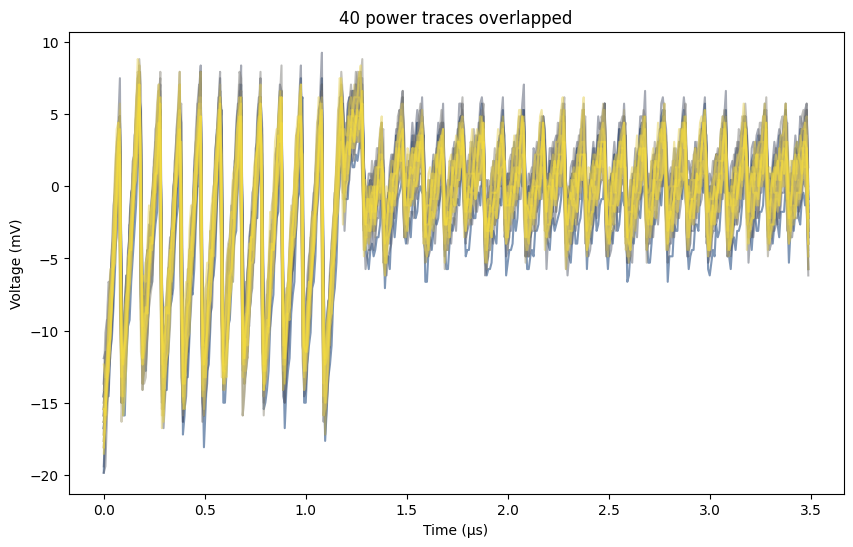

In [7]:
if traces_overlapped_plot:
    # Re-open the project for offline analysis
    try:
        with h5py.File(TRACESET_FILE, 'r') as f_read_traces:
            # Load the traces and labels into RAM
            all_traces = f_read_traces['traces'][()]
            all_labels = f_read_traces['labels'][()]
            
        # Separate the traces based on TVLA label (0 = fixed, 1 = random)
        fixed_traces = all_traces[all_labels == 0]
        random_traces = all_traces[all_labels == 1]
        
        # Read the first 20 fixed and 20 random traces
        traces_to_plot = list(fixed_traces[:20]) + list(random_traces[:20])

        print("Generating power traces overlapped plot (20 fixed, 20 random)...")
        sca_plt = sca_plot()
        power_plt = sca_plt.power_traces_overlapped(
            traces_to_plot, 
            sampling_interval
        )

        out_file = (
            PLOT_DIR / f"AES_TVLA_power_traces_overlapped_{sbox_id}.pdf"
        )
        if (save_plot):
            power_plt.savefig(out_file)
        power_plt.show()
    except FileNotFoundError:
        print(f"ERROR: Traces file {TRACESET_FILE} not found. Please run the trace acquisition phase first.")